# CNN 3D con Conv3D: clasificación de esfera vs. cubo

Este cuaderno complementa el cuaderno 2D y entrena un **modelo independiente**. Usa volúmenes sintéticos de `16×16×16` con un canal para enseñar `Conv3D` y `MaxPooling3D`. No usa MNIST, porque MNIST contiene imágenes 2D.

**Clases:** esfera (0) y cubo (1). Al final se evalúa y guarda `esfera_cubo_conv3d.keras` en tu Drive.

> Para proyectos reales, reemplaza estos datos sintéticos por volúmenes 3D reales (por ejemplo, voxels o imágenes médicas volumétricas).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)

# --- Guardar los modelos en tu Drive (no se pierden al cerrar Colab) ---
import os
from google.colab import drive
drive.mount('/content/drive')
CARPETA = '/content/drive/MyDrive/modelos_cnn'
os.makedirs(CARPETA, exist_ok=True)
print("Los modelos se guardaran en:", CARPETA)


TensorFlow: 2.21.0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Los modelos se guardaran en: /content/drive/MyDrive/modelos_cnn


## 1. Generar datos tridimensionales de ejemplo

In [2]:
def crear_volumen(etiqueta, rng, tam=16):
    coords = np.indices((tam, tam, tam)).astype(np.float32)
    centro = np.array([tam/2 + rng.uniform(-1, 1) for _ in range(3)], dtype=np.float32)
    dx, dy, dz = coords[0]-centro[0], coords[1]-centro[1], coords[2]-centro[2]
    if etiqueta == 0:  # esfera
        radio = rng.uniform(4.0, 5.2)
        mascara = dx**2 + dy**2 + dz**2 <= radio**2
    else:  # cubo
        lado = rng.uniform(4.0, 5.2)
        mascara = (np.abs(dx) <= lado) & (np.abs(dy) <= lado) & (np.abs(dz) <= lado)
    volumen = mascara.astype(np.float32)
    volumen += rng.normal(0, 0.06, volumen.shape).astype(np.float32)
    return np.clip(volumen, 0, 1)

rng = np.random.default_rng(42)
n = 1200
X = np.empty((n, 16, 16, 16, 1), dtype=np.float32)
y = np.empty(n, dtype=np.int32)
for i in range(n):
    y[i] = i % 2
    X[i, ..., 0] = crear_volumen(int(y[i]), rng)
orden = rng.permutation(n)
X, y = X[orden], y[orden]
print("Forma de X:", X.shape)  # muestras, profundidad, alto, ancho, canales
print("Forma de y:", y.shape)

Forma de X: (1200, 16, 16, 16, 1)
Forma de y: (1200,)


## 2. Visualizar tres cortes de un volumen

Etiqueta: cubo


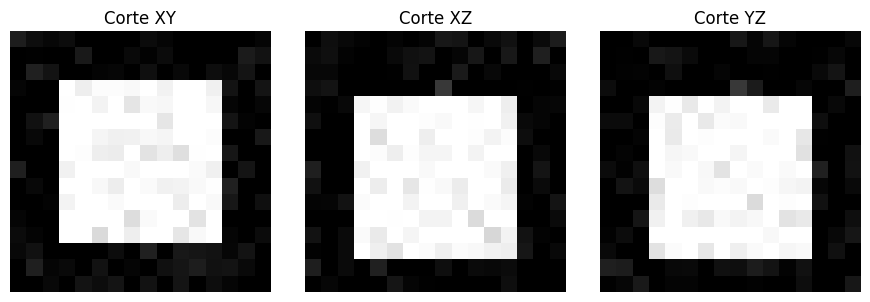

In [3]:
i = 0
vol = X[i, ..., 0]
print("Etiqueta:", "esfera" if y[i] == 0 else "cubo")
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, corte, titulo in zip(axes, [vol[8], vol[:, 8, :], vol[:, :, 8]], ["Corte XY", "Corte XZ", "Corte YZ"]):
    ax.imshow(corte, cmap="gray", vmin=0, vmax=1)
    ax.set_title(titulo)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Separar entrenamiento, validación y prueba

In [4]:
n_train = int(len(X) * 0.70)
n_val = int(len(X) * 0.15)
X_train, y_train = X[:n_train], y[:n_train]
X_val, y_val = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test, y_test = X[n_train+n_val:], y[n_train+n_val:]
print("Entrenamiento:", X_train.shape)
print("Validación:", X_val.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (840, 16, 16, 16, 1)
Validación: (180, 16, 16, 16, 1)
Prueba: (180, 16, 16, 16, 1)


## 4. Construir la CNN 3D\n\n`Conv3D` aprende patrones en tres dimensiones; `MaxPooling3D` reduce el volumen; `GlobalAveragePooling3D` resume características; `Dense` realiza la clasificación final.

In [5]:
modelo_3d = keras.Sequential([
    keras.Input(shape=(16, 16, 16, 1)),
    layers.Conv3D(16, 3, padding="same", activation="relu"),
    layers.MaxPooling3D(2),
    layers.Conv3D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling3D(2),
    layers.Conv3D(64, 3, padding="same", activation="relu"),
    layers.GlobalAveragePooling3D(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.25),
    layers.Dense(1, activation="sigmoid")
])
modelo_3d.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
modelo_3d.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 16, 16, 16, 16) │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 8, 8, 8, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 8, 8, 8, 32)    │        13,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 4, 4, 4, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 4, 4, 4, 64)    │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,777 (280.38 KB)

 Trainable params: 71,777 (280.38 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenar el modelo

In [6]:
parada_temprana = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=4, restore_best_weights=True
)
historial = modelo_3d.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15, batch_size=16,
    callbacks=[parada_temprana],
    verbose=1
)

Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.7083 - loss: 0.5493 - val_accuracy: 0.9278 - val_loss: 0.2717
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9833 - loss: 0.0750 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 6.2408e-04
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 1.2606e-04
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.3149e-04 - val_accuracy: 1.0000 - val_loss: 6.4045e-05
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 8.7047e-04 - val_accuracy: 1.0000 - val_loss: 9.4813e-05
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 5.2354e-04 - val_accuracy: 1.0000 - val_loss: 2.0383e-05
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 3.3246

## 6. Graficar precisión y pérdida

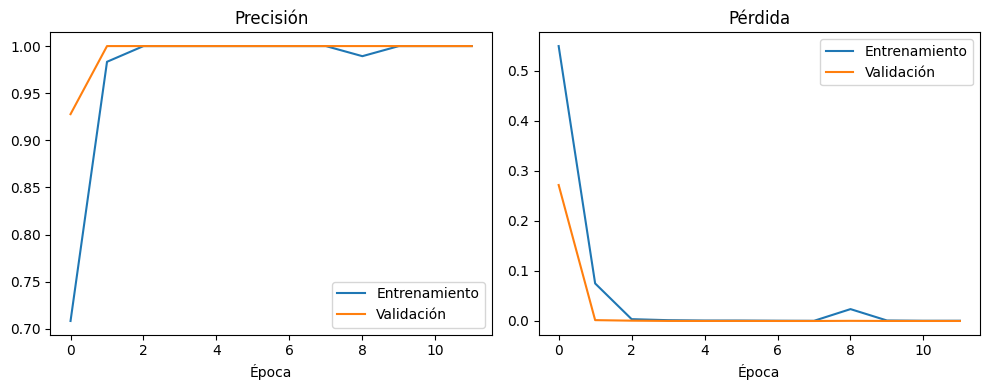

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(historial.history["accuracy"], label="Entrenamiento")
axes[0].plot(historial.history["val_accuracy"], label="Validación")
axes[0].set_title("Precisión"); axes[0].set_xlabel("Época"); axes[0].legend()
axes[1].plot(historial.history["loss"], label="Entrenamiento")
axes[1].plot(historial.history["val_loss"], label="Validación")
axes[1].set_title("Pérdida"); axes[1].set_xlabel("Época"); axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Evaluar con datos de prueba

In [8]:
loss_test, acc_test = modelo_3d.evaluate(X_test, y_test, verbose=0)
print(f"Pérdida en prueba: {loss_test:.4f}")
print(f"Precisión en prueba: {acc_test:.4f}")

Pérdida en prueba: 0.0000
Precisión en prueba: 1.0000


## 8. Probar una predicción

In [9]:
i = 0
prob_cubo = float(modelo_3d.predict(X_test[i:i+1], verbose=0)[0, 0])
pred = int(prob_cubo >= 0.5)
print(f"Probabilidad de cubo: {prob_cubo:.3f}")
print("Predicción:", "cubo" if pred == 1 else "esfera")
print("Etiqueta real:", "cubo" if y_test[i] == 1 else "esfera")

Probabilidad de cubo: 1.000
Predicción: cubo
Etiqueta real: cubo


## 9. Guardar y volver a cargar el modelo

In [10]:
modelo_3d.save(f"{CARPETA}/esfera_cubo_conv3d.keras")
print("Guardado como esfera_cubo_conv3d.keras")

# Para reutilizarlo posteriormente:
modelo_cargado = keras.models.load_model(f"{CARPETA}/esfera_cubo_conv3d.keras")
modelo_cargado.summary()

Guardado como esfera_cubo_conv3d.keras


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 16, 16, 16, 16) │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 8, 8, 8, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 8, 8, 8, 32)    │        13,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 4, 4, 4, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 4, 4, 4, 64)    │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,333 (841.15 KB)

 Trainable params: 71,777 (280.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 143,556 (560.77 KB)

## Conclusiones

- Este cuaderno produce un modelo CNN 3D separado del modelo 2D.
- Cada modelo tiene sus propios pesos y se entrena por separado.
- Puedes mantener ambos cuadernos o incluir secciones independientes en uno solo; recomiendo cuadernos separados para mayor claridad.
- No basta con cambiar `Conv2D` por `Conv3D`: también cambia la forma de entrada y se necesitan datos que representen volúmenes 3D.